https://otexts.com/fpppy/

In [ ]:
!unzip fpppy_data.zip

Archive:  fpppy_data.zip
   creating: data/
  inflating: data/austa.csv          
  inflating: data/aus_retail.csv     
  inflating: data/canadian_gas.csv   
  inflating: data/gafa_stock.csv     
  inflating: data/hsales.csv         
  inflating: data/prison_population.csv  
  inflating: data/EPF_FR_BE_futr.csv  
  inflating: data/algeria_exports_unparsed.csv  
  inflating: data/USAccDeaths.csv    
  inflating: data/guinea_rice.csv    
  inflating: data/hsales_unparsed.csv  
  inflating: data/algeria_exports.csv  
  inflating: data/lake_huron.csv     
  inflating: data/insurance.csv      
  inflating: data/eggs.csv           
  inflating: data/aus_production.csv  
  inflating: data/us_total.csv       
  inflating: data/electricity_future_vars.csv  
  inflating: data/tute1.csv          
  inflating: data/total_cost_df.csv  
  inflating: data/pbs.csv            
  inflating: data/PBS_unparsed.csv   
  inflating: data/aus_tourism.csv    
  inflating: data/aus_arrivals.csv   
  inflating: 

In [ ]:
!pip install utilsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip install coreforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 6.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import utilsforecast.plotting as uf
import matplotlib.pyplot as plt
import seaborn as sns
from coreforecast.scalers import boxcox_lambda, boxcox
from statsmodels.tsa.seasonal import STL, seasonal_decompose

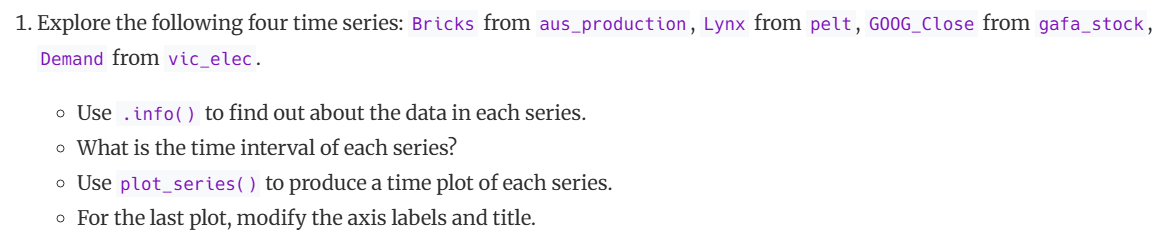

#####Bricks

In [ ]:
bricks_df = pd.read_csv("/content/data/aus_production.csv", parse_dates=["ds"])

In [ ]:
bricks_df

,ds,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956-01-01,284,5225.0,189.0,465,3923,5
1,1956-04-01,213,5178.0,204.0,532,4436,6
2,1956-07-01,227,5297.0,208.0,561,4806,7
3,1956-10-01,308,5681.0,197.0,570,4418,6
4,1957-01-01,262,5577.0,187.0,529,4339,5
...,...,...,...,...,...,...,...
213,2009-04-01,398,NaN,NaN,2160,57471,238
214,2009-07-01,419,NaN,NaN,2325,58394,252
215,2009-10-01,488,NaN,NaN,2273,57336,210
216,2010-01-01,414,NaN,NaN,1904,58309,205


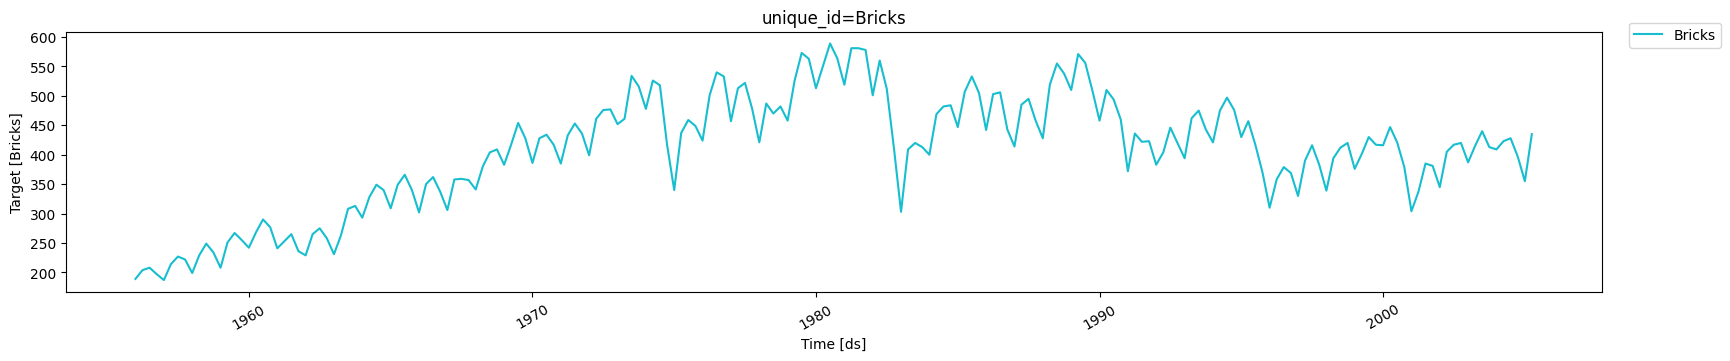

In [ ]:
uf.plot_series(bricks_df.assign(unique_id="Bricks"), target_col="Bricks")

#####Lynx

In [ ]:
lynx_df = pd.read_csv("./data/pelt.csv", parse_dates=["ds"])

In [ ]:
lynx_df

,unique_id,ds,y
0,hare,1845-01-01,19580
1,hare,1846-01-01,19600
2,hare,1847-01-01,19610
3,hare,1848-01-01,11990
4,hare,1849-01-01,28040
...,...,...,...
177,lynx,1931-01-01,8310
178,lynx,1932-01-01,16010
179,lynx,1933-01-01,24820
180,lynx,1934-01-01,29700


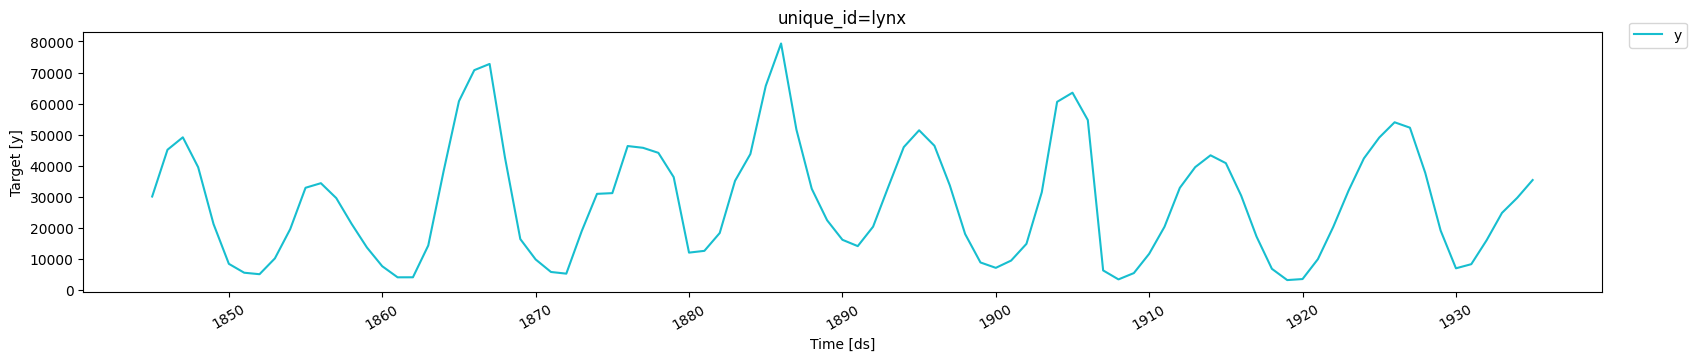

In [ ]:
uf.plot_series(lynx_df.loc[lambda x: x["unique_id"] == "lynx"], target_col="y")

####GOOG__close


In [ ]:
goog_df = pd.read_csv("./data/gafa_stock.csv", parse_dates=["ds"])

In [ ]:
goog_df

,unique_id,ds,y
0,AAPL_Open,2014-01-02,7.938286e+01
1,AAPL_Open,2014-01-03,7.898000e+01
2,AAPL_Open,2014-01-06,7.677857e+01
3,AAPL_Open,2014-01-07,7.776000e+01
4,AAPL_Open,2014-01-08,7.697285e+01
...,...,...,...
30187,GOOG_Volume,2018-12-24,1.590300e+06
30188,GOOG_Volume,2018-12-26,2.373300e+06
30189,GOOG_Volume,2018-12-27,2.109800e+06
30190,GOOG_Volume,2018-12-28,1.414800e+06


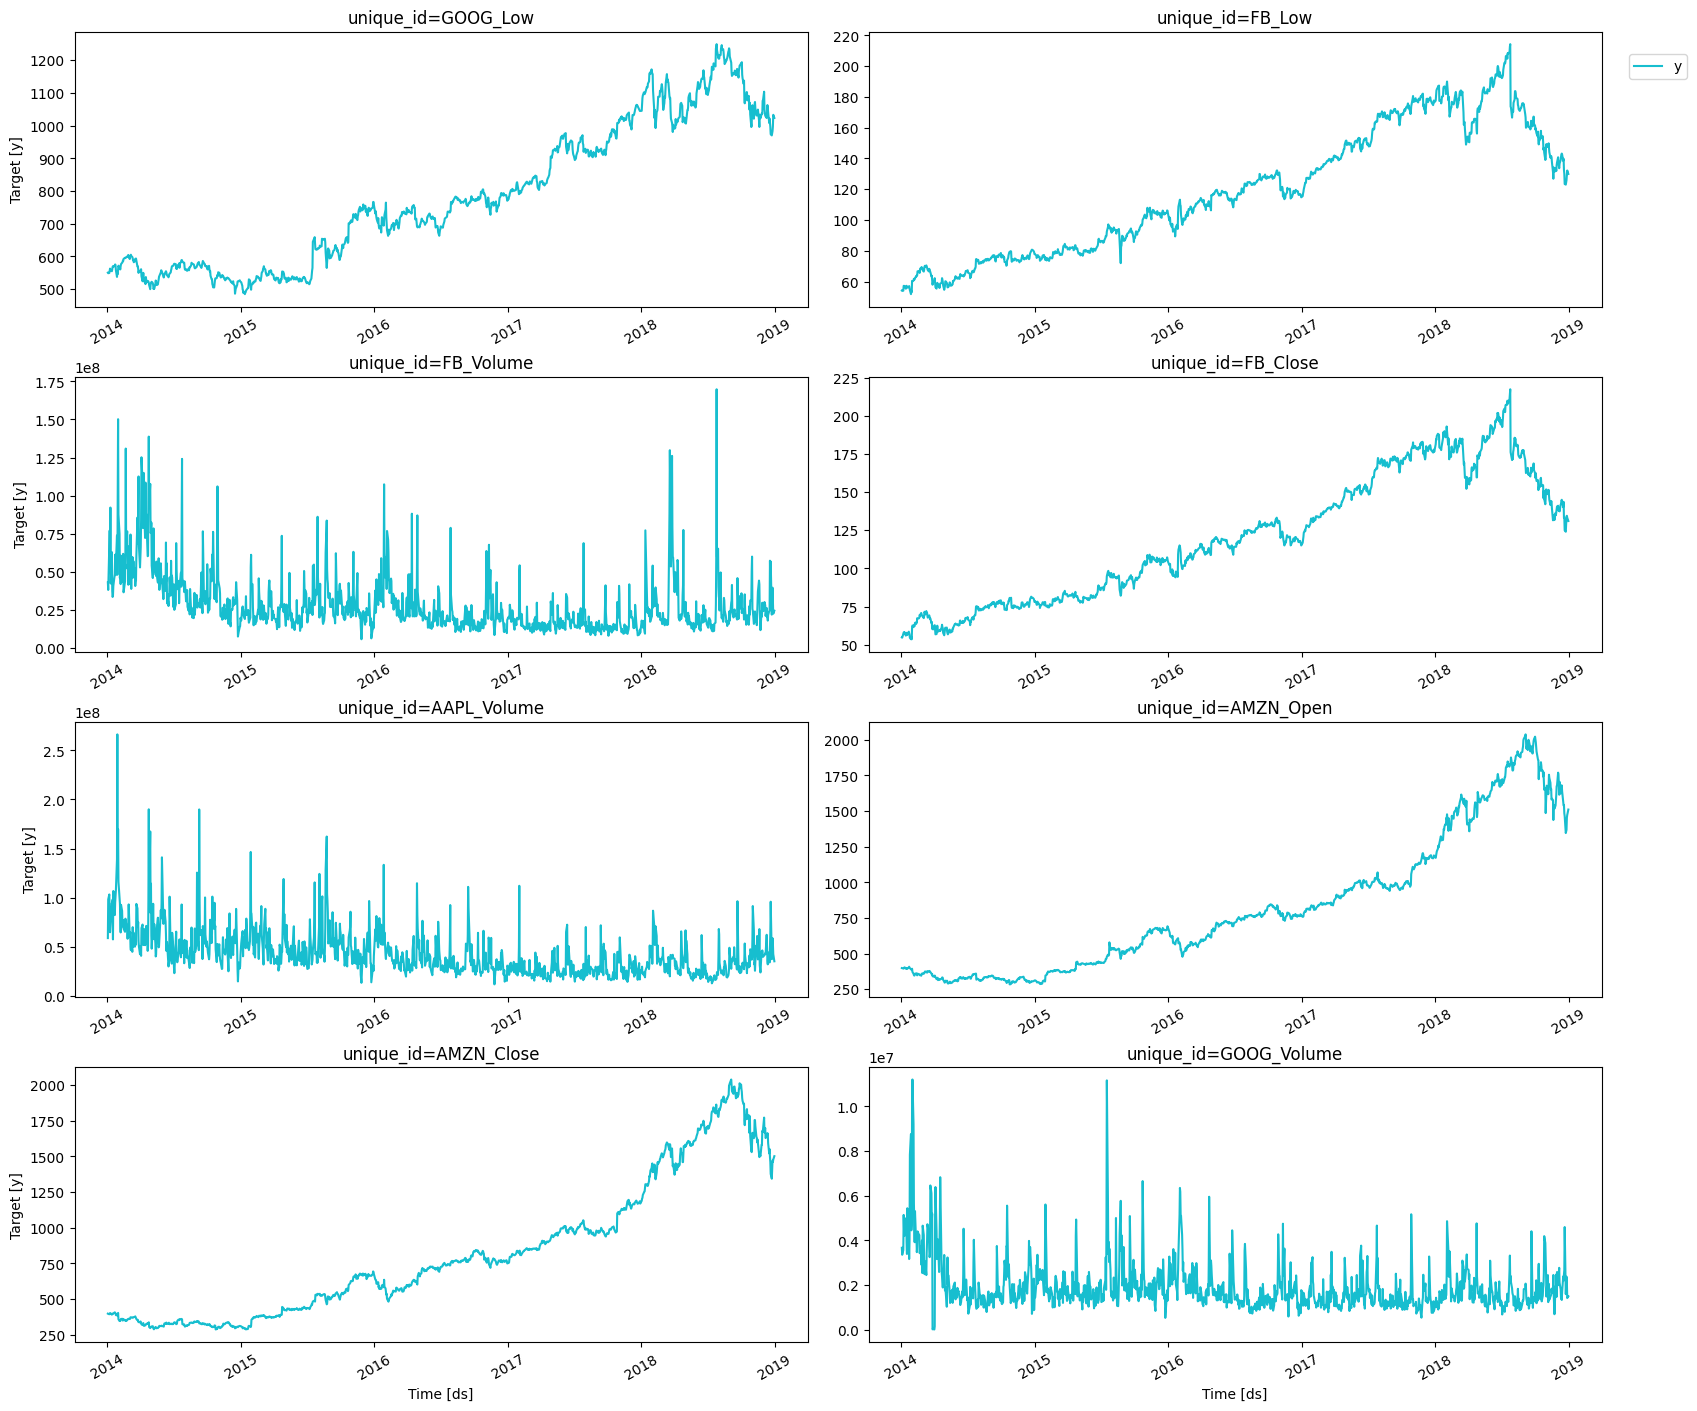

In [ ]:
fig = uf.plot_series(goog_df, target_col="y")
fig

####us_total

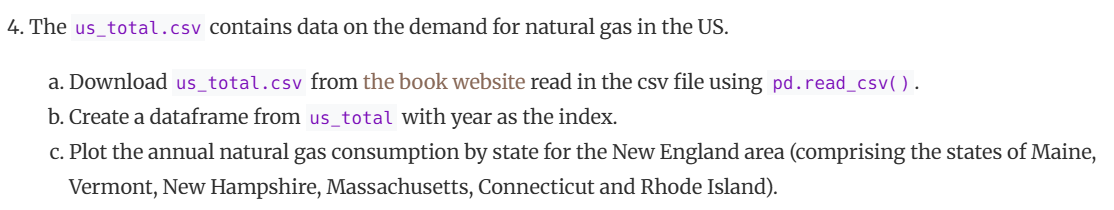

In [ ]:
us_total_df = pd.read_csv("./data/us_total.csv")

In [ ]:
us_total = us_total_df.set_index("ds")

In [ ]:
states = ["Maine", "Vermont", "New Hampshire", "Massachusets", "Connecticut", "Rhode Island"]
"Maine" in states

True

In [ ]:
us_total.loc[lambda x: x["unique_id"].isin(states)]

,unique_id,y
ds,,
1997,Connecticut,144708
1998,Connecticut,131497
1999,Connecticut,152237
2000,Connecticut,159712
2001,Connecticut,146278
...,...,...
2015,Vermont,11950
2016,Vermont,12094
2017,Vermont,11926


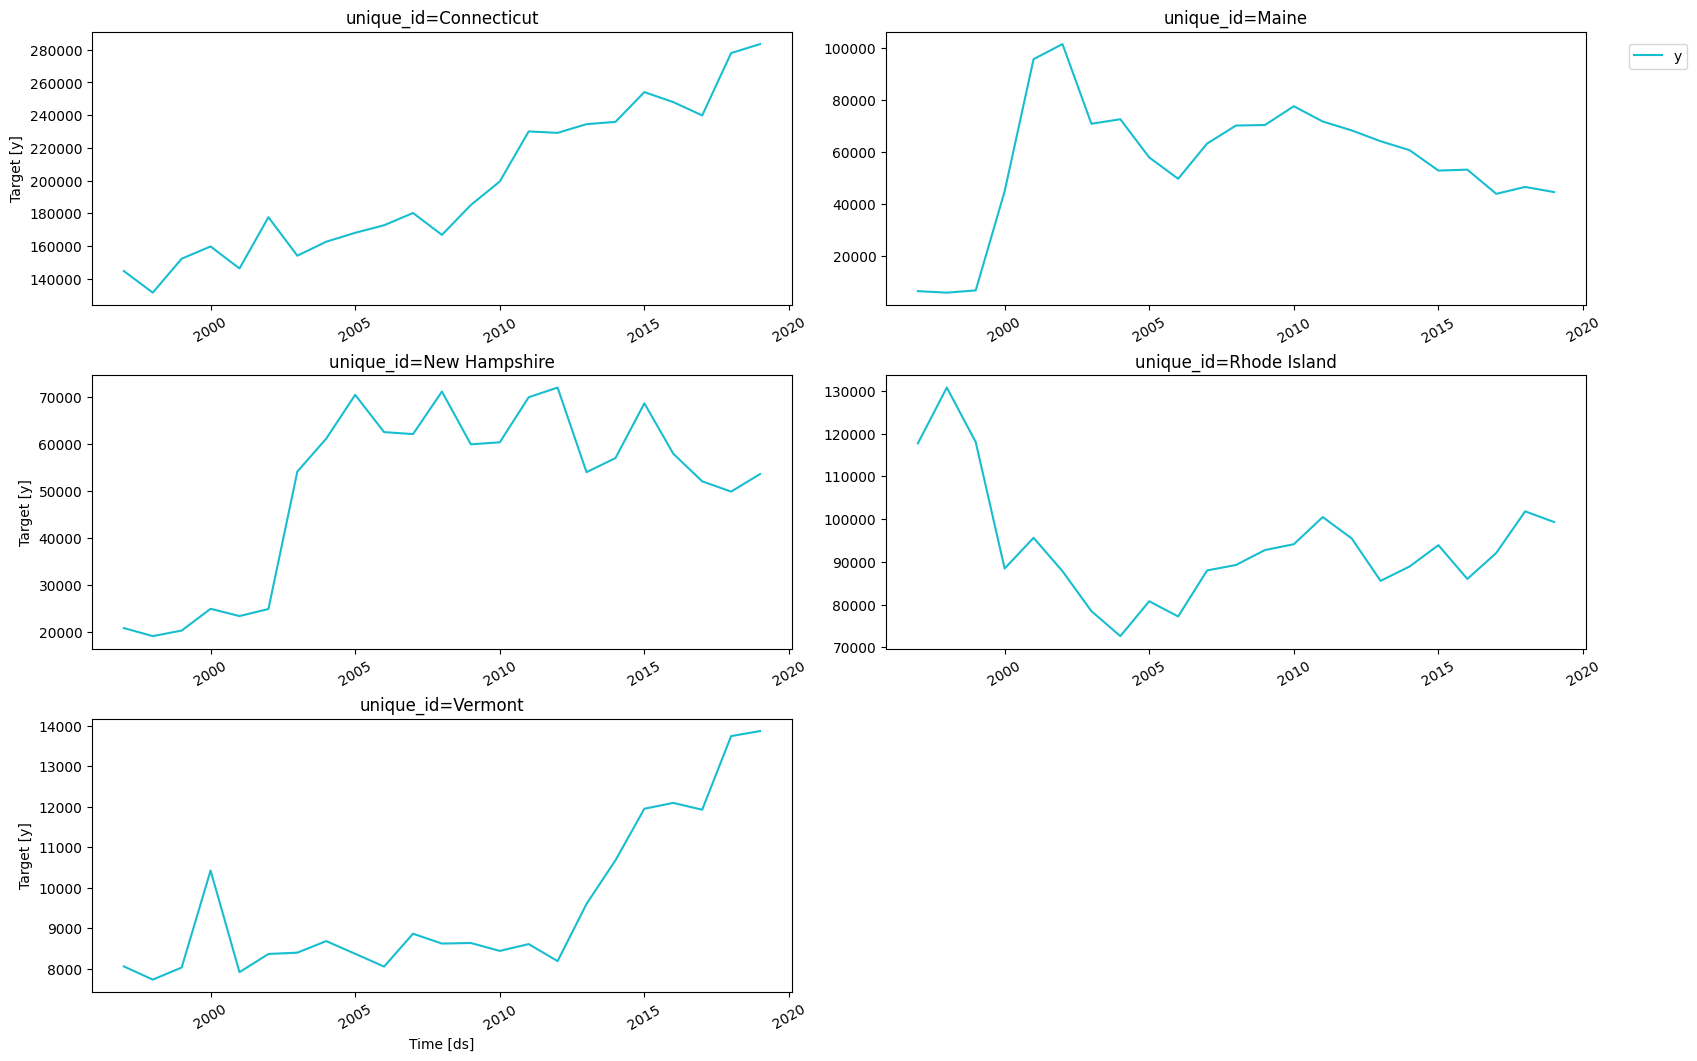

In [ ]:
uf.plot_series(us_total_df.loc[lambda x: x["unique_id"].isin(states)], target_col="y")

####aus_arrival

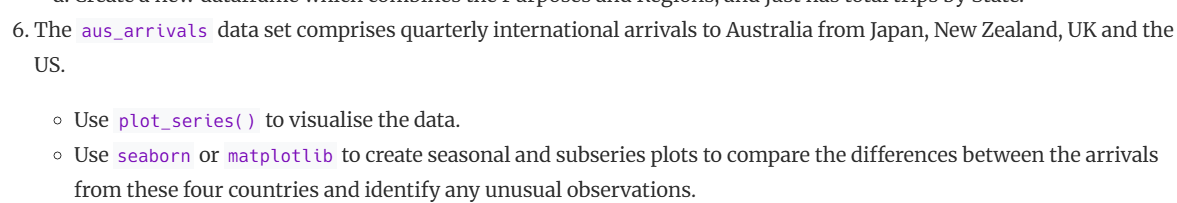

In [ ]:
aus_df = pd.read_csv("./data/aus_arrivals.csv", parse_dates=["Quarter"])

In [ ]:
aus_df

,Quarter,Origin,Arrivals
0,1981-01-01,Japan,14763
1,1981-04-01,Japan,9321
2,1981-07-01,Japan,10166
3,1981-10-01,Japan,19509
4,1982-01-01,Japan,17117
...,...,...,...
503,2011-07-01,US,101925
504,2011-10-01,US,127150
505,2012-01-01,US,129520
506,2012-04-01,US,105700


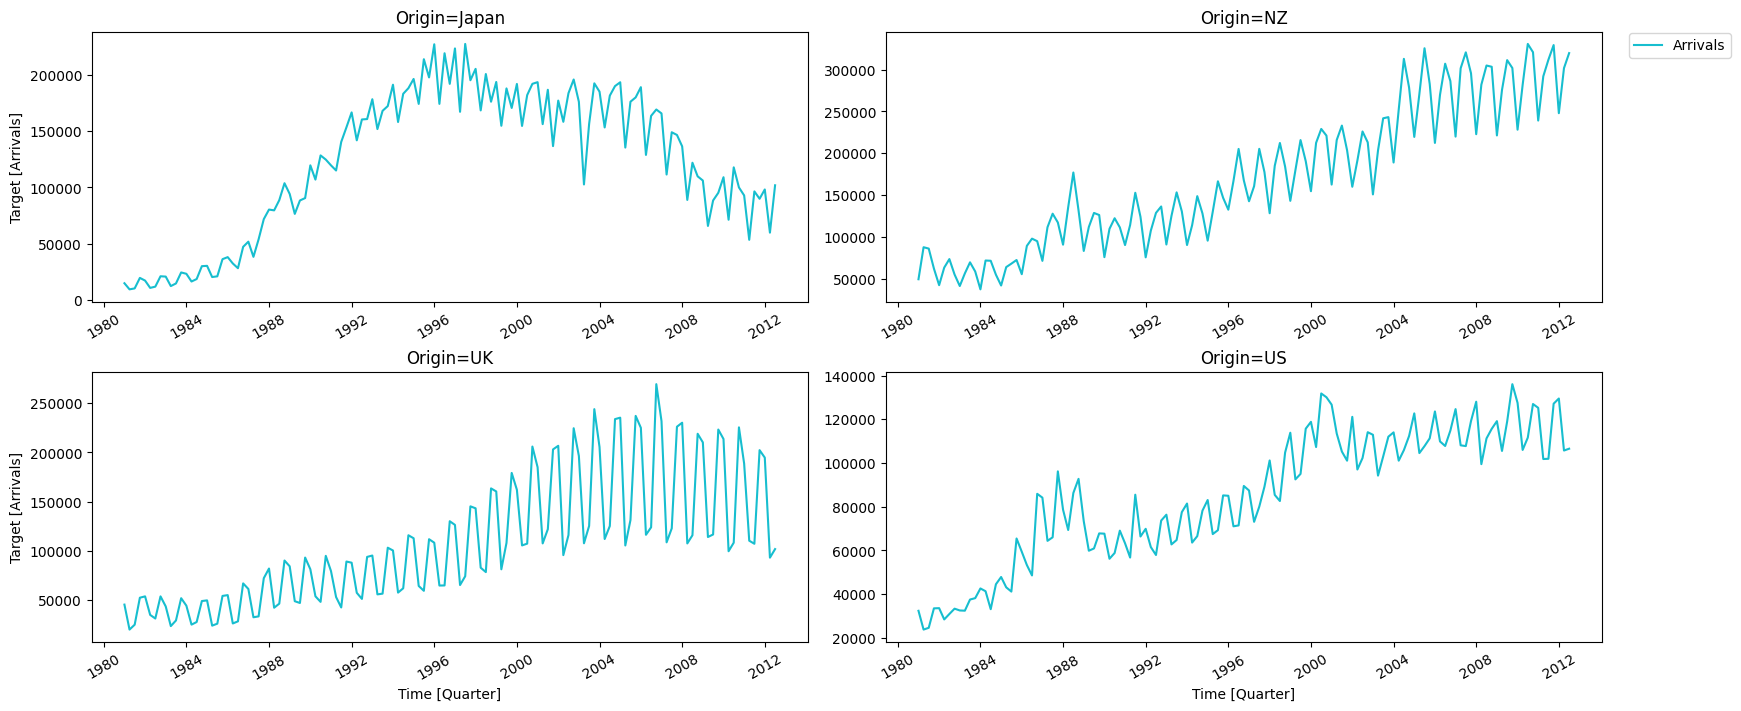

In [ ]:
uf.plot_series(aus_df, id_col="Origin", time_col="Quarter", target_col="Arrivals")

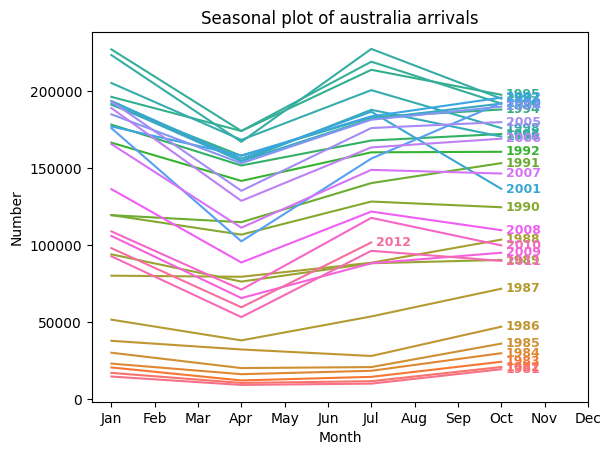

In [ ]:
df = aus_df.loc[aus_df["Origin"]=="Japan"].assign(
    Month_name = aus_df["Quarter"].dt.strftime("%b"),
    Year = aus_df["Quarter"].dt.year,
    Month_num = aus_df["Quarter"].dt.month
)
unique_years = df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))

fig, ax = plt.subplots()
sns.lineplot(data = df, x="Month_num", y="Arrivals", hue="Year", palette=year_palette, ax=ax, legend=False)
ax.set(
    title = "Seasonal plot of australia arrivals",
    xlabel = "Month",
    ylabel = "Number",
    xticks = range(1, 13),
    xticklabels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Arrivals"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="center", fontsize=9, weight="bold", color=color)
fig.show()

###lesson 3

#####task 1

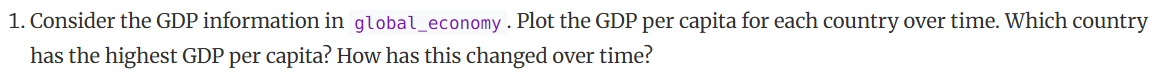

In [ ]:
global_economy_df = pd.read_csv("./data/global_economy.csv")

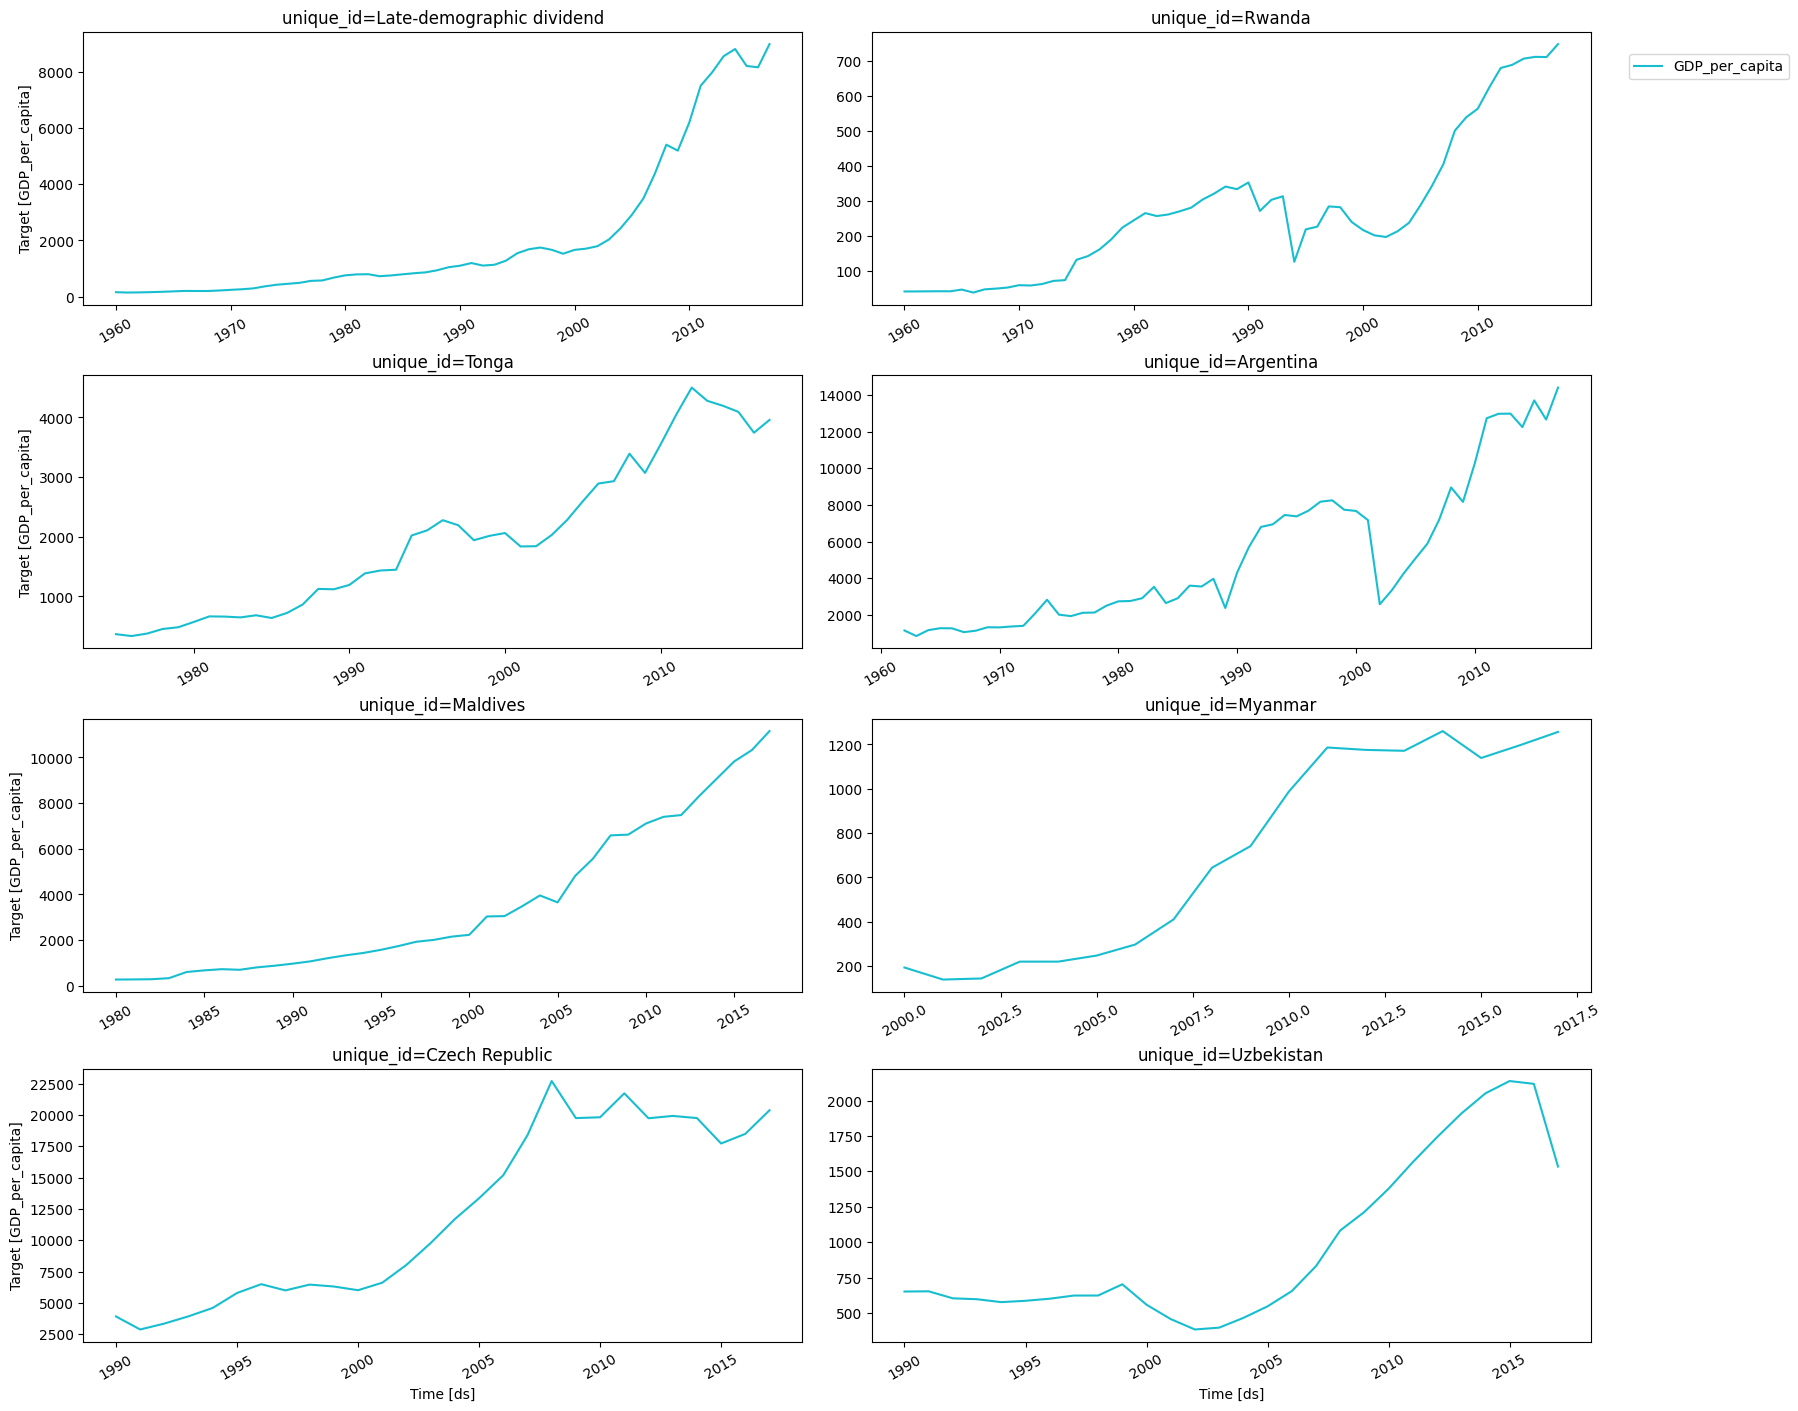

In [ ]:
uf.plot_series(global_economy_df.assign(GDP_per_capita = lambda x: x["GDP"]/x["Population"]), target_col="GDP_per_capita")

####task 3

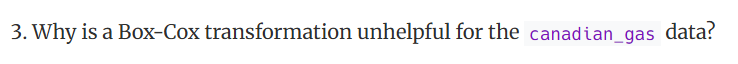

In [ ]:
canadian_gas_df = pd.read_csv("./data/canadian_gas.csv", parse_dates=["ds"])

In [ ]:
canadian_gas_df

,unique_id,ds,y
0,Canadian gas production,1960-01-01,1.4306
1,Canadian gas production,1960-02-01,1.3059
2,Canadian gas production,1960-03-01,1.4022
3,Canadian gas production,1960-04-01,1.1699
4,Canadian gas production,1960-05-01,1.1161
...,...,...,...
537,Canadian gas production,2004-10-01,17.8268
538,Canadian gas production,2004-11-01,17.8322
539,Canadian gas production,2004-12-01,19.4526
540,Canadian gas production,2005-01-01,19.5284


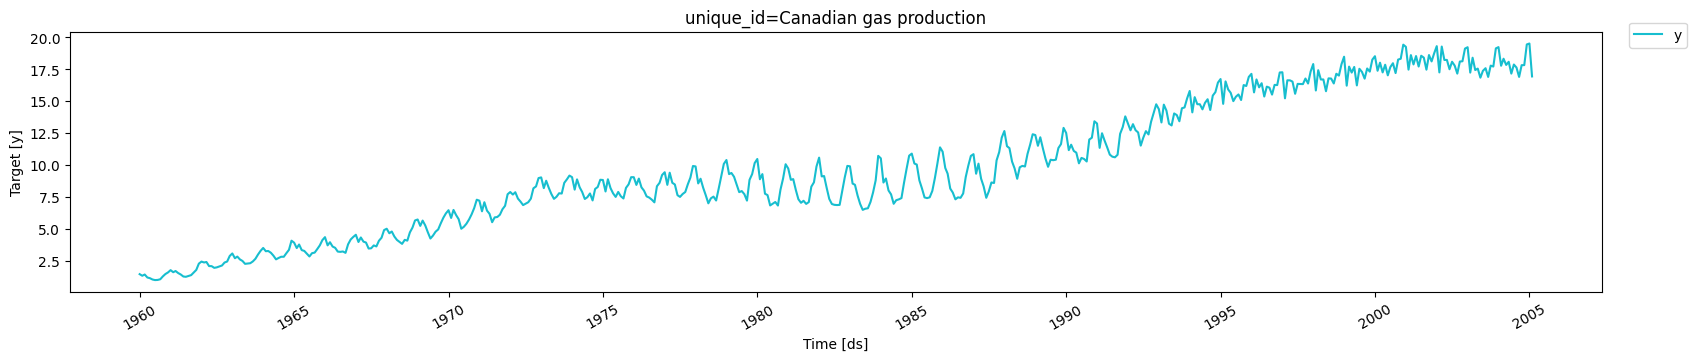

In [ ]:
uf.plot_series(canadian_gas_df, target_col="y")

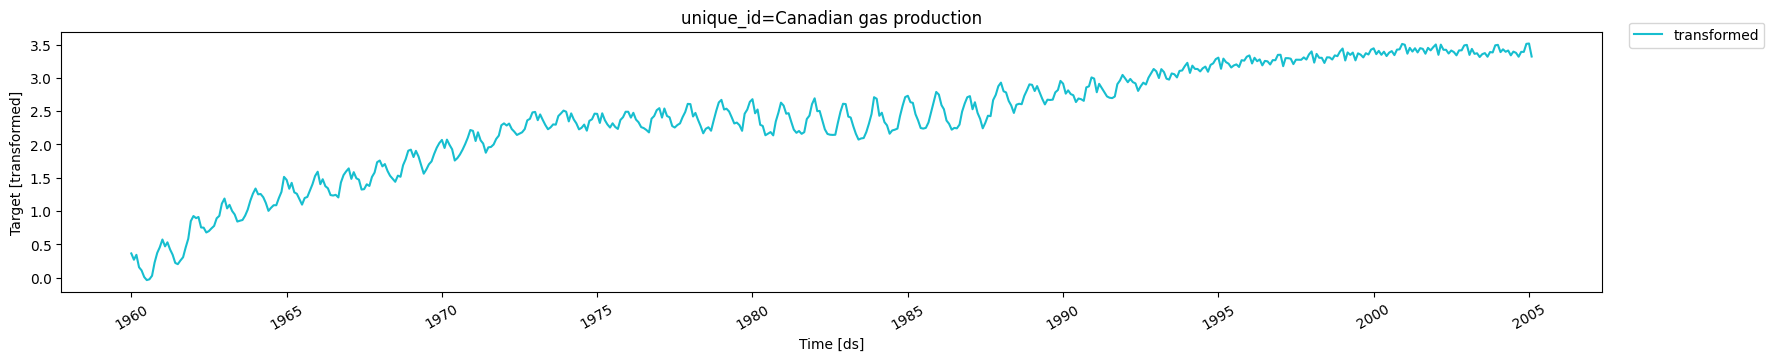

In [ ]:
uf.plot_series(canadian_gas_df.assign(transformed=lambda x: boxcox(x["y"], 0.11)), target_col="transformed")

####task 7

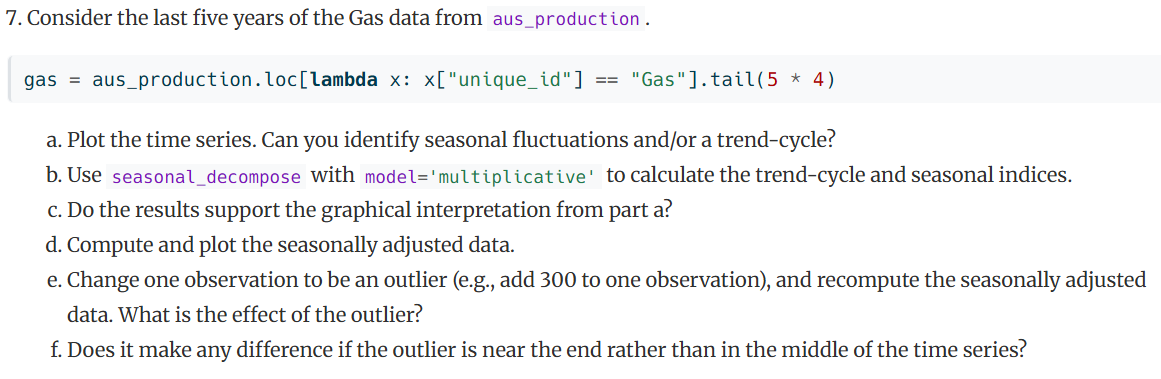

In [ ]:
aus_production_df = pd.read_csv("./data/aus_production.csv", parse_dates=["ds"]).drop(["Beer", "Tobacco", "Bricks", "Cement", "Electricity"], axis=1).tail(20)

In [ ]:
aus_production_df

,ds,Gas
198,2005-07-01,221
199,2005-10-01,180
200,2006-01-01,171
201,2006-04-01,224
202,2006-07-01,233
203,2006-10-01,192
204,2007-01-01,187
205,2007-04-01,234
206,2007-07-01,245
207,2007-10-01,205


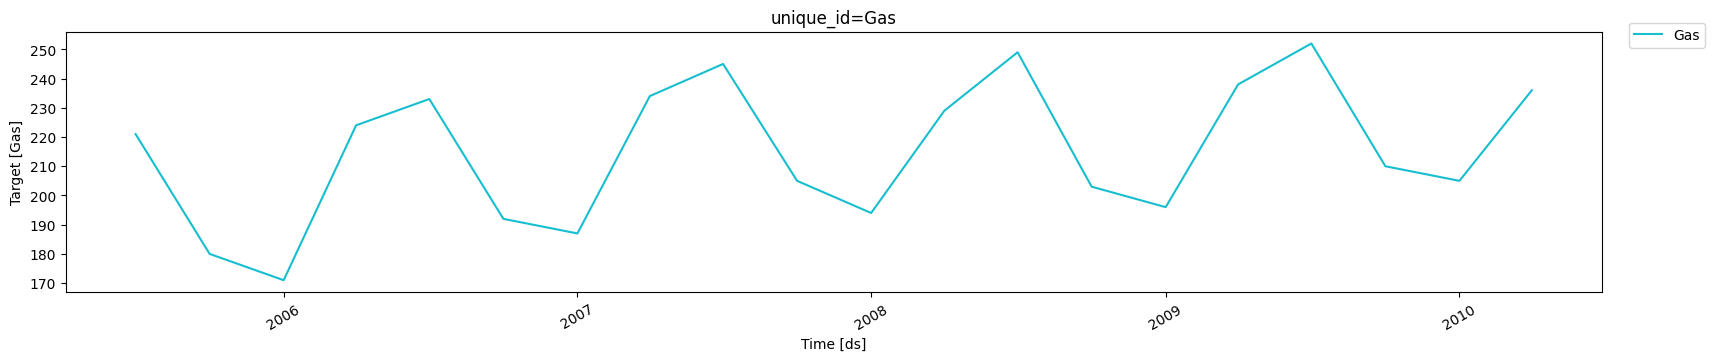

In [ ]:
uf.plot_series(aus_production_df.assign(unique_id="Gas"), target_col="Gas")

In [ ]:
model = seasonal_decompose(aus_production_df.set_index("ds"), model="multiplicative")

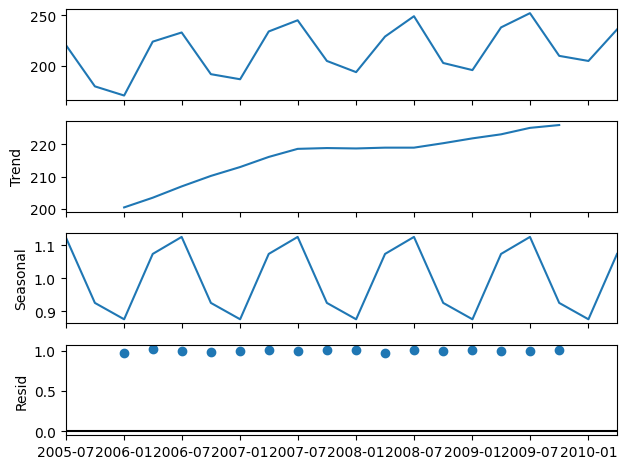

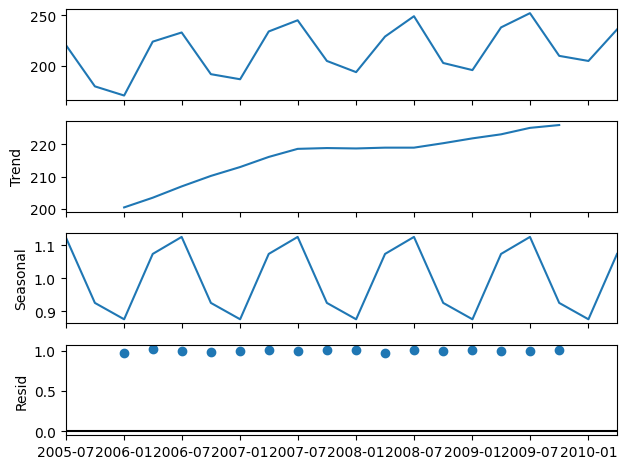

In [ ]:
model.plot()

In [ ]:
model.trend

,trend
ds,
2005-07-01,NaN
2005-10-01,NaN
2006-01-01,200.500
2006-04-01,203.500
2006-07-01,207.000
2006-10-01,210.250
2007-01-01,213.000
2007-04-01,216.125
2007-07-01,218.625


In [ ]:
trend_adjusted_df = aus_production_df.copy()
trend_adjusted_df["New_Gas"] = trend_adjusted_df["Gas"].values - model.trend.values

In [ ]:
trend_adjusted_df

,ds,Gas,New_Gas
198,2005-07-01,221,NaN
199,2005-10-01,180,NaN
200,2006-01-01,171,-29.500
201,2006-04-01,224,20.500
202,2006-07-01,233,26.000
203,2006-10-01,192,-18.250
204,2007-01-01,187,-26.000
205,2007-04-01,234,17.875
206,2007-07-01,245,26.375
207,2007-10-01,205,-13.875


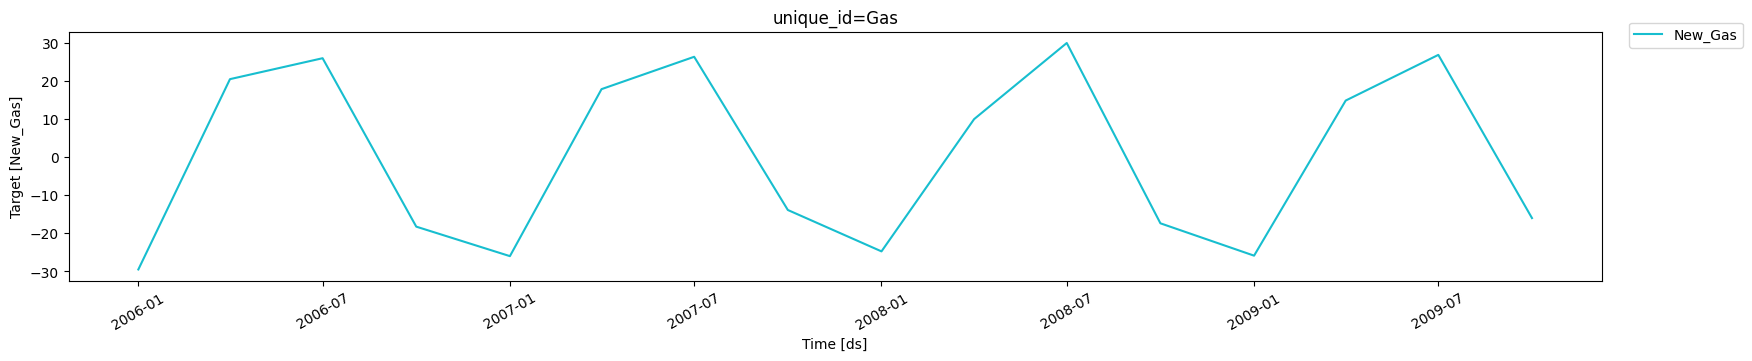

In [ ]:
uf.plot_series(trend_adjusted_df.assign(unique_id="Gas"), target_col="New_Gas")

In [ ]:
new_df = aus_production_df.copy()
new_df.at[212, "Gas"] = 496

In [ ]:
new_df

,ds,Gas
198,2005-07-01,221
199,2005-10-01,180
200,2006-01-01,171
201,2006-04-01,224
202,2006-07-01,233
203,2006-10-01,192
204,2007-01-01,187
205,2007-04-01,234
206,2007-07-01,245
207,2007-10-01,205


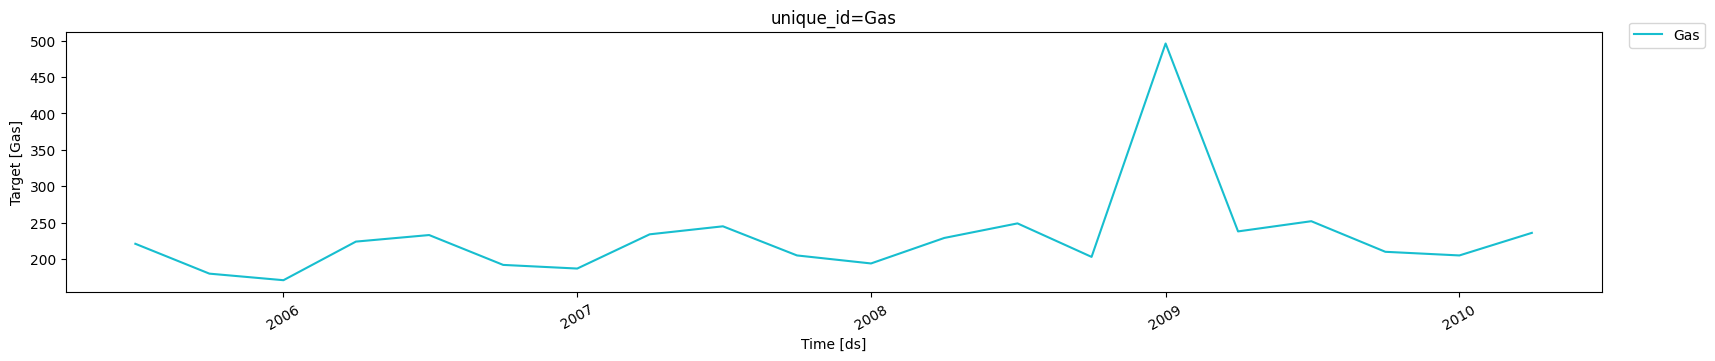

In [ ]:
uf.plot_series(new_df.assign(unique_id="Gas"), target_col="Gas")

In [ ]:
model_new = seasonal_decompose(new_df.set_index("ds"), model="multiplicative")

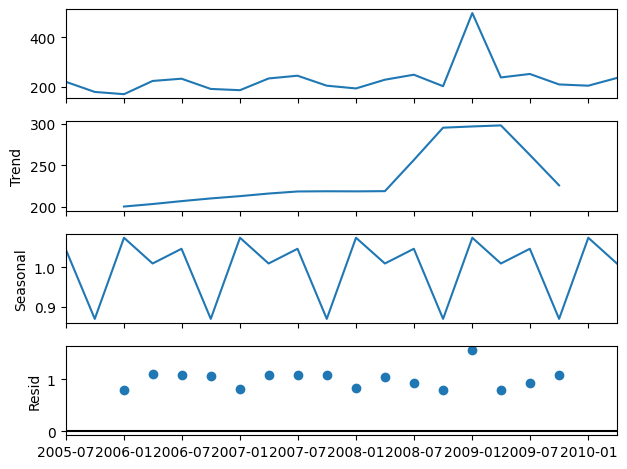

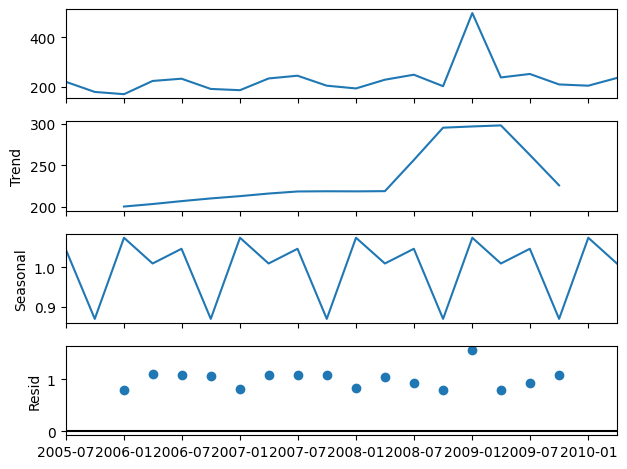

In [ ]:
model_new.plot()

In [ ]:
new_trend_adjusted_df = new_df.copy()
new_trend_adjusted_df["New_Gas"] = new_df["Gas"].values - model_new.trend.values

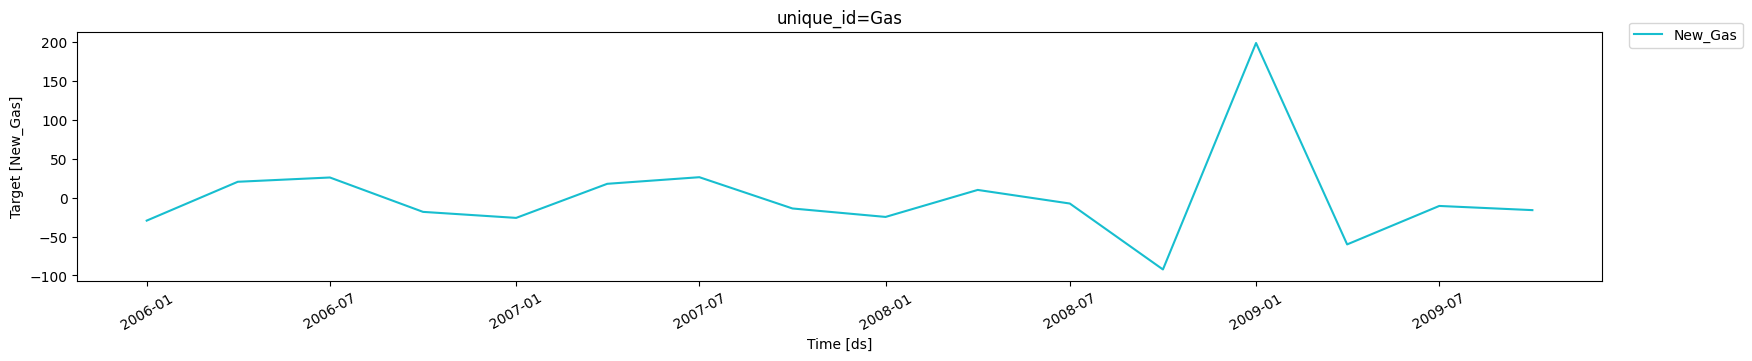

In [ ]:
uf.plot_series(new_trend_adjusted_df.assign(unique_id="Gas"), target_col="New_Gas")

####task 10

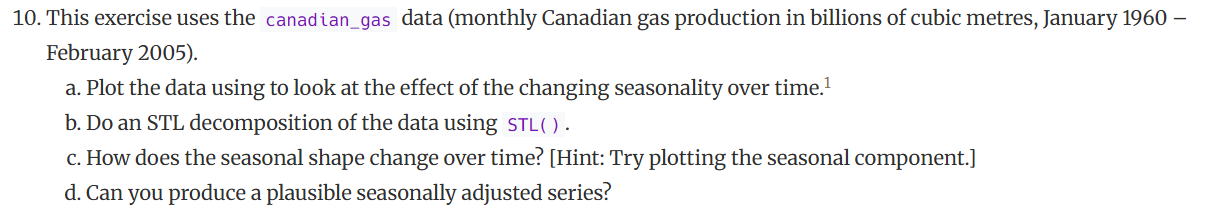

In [ ]:
canadian_gas_df = pd.read_csv("./data/canadian_gas.csv", parse_dates=["ds"])

In [ ]:
canadian_gas_df

,unique_id,ds,y
0,Canadian gas production,1960-01-01,1.4306
1,Canadian gas production,1960-02-01,1.3059
2,Canadian gas production,1960-03-01,1.4022
3,Canadian gas production,1960-04-01,1.1699
4,Canadian gas production,1960-05-01,1.1161
...,...,...,...
537,Canadian gas production,2004-10-01,17.8268
538,Canadian gas production,2004-11-01,17.8322
539,Canadian gas production,2004-12-01,19.4526
540,Canadian gas production,2005-01-01,19.5284


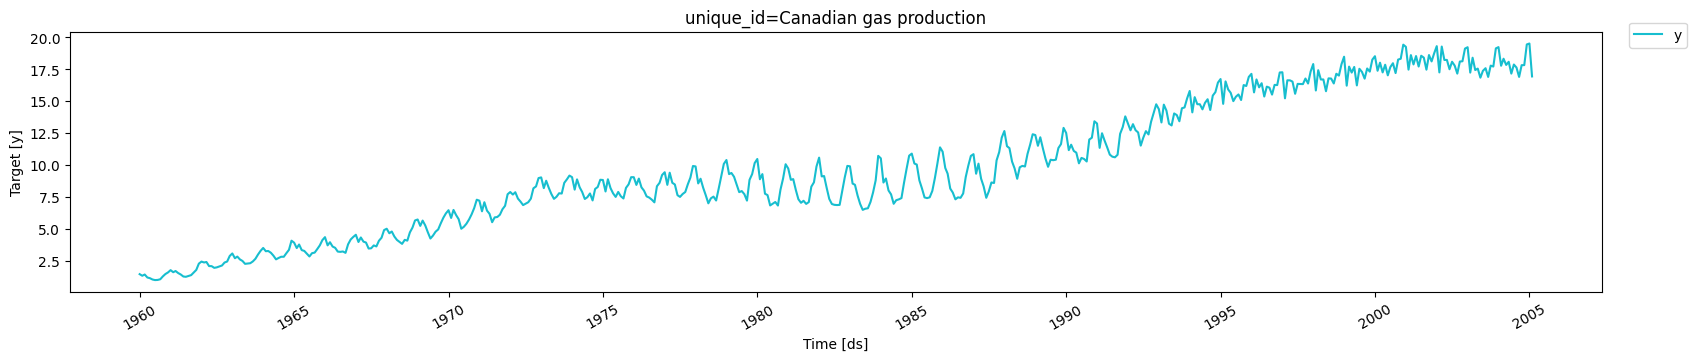

In [ ]:
uf.plot_series(canadian_gas_df, target_col="y")

In [ ]:
stl = STL(canadian_gas_df["y"], period=12, seasonal=13, trend = 21)

In [ ]:
res_stl = stl.fit()

In [ ]:
dcmp = pd.DataFrame({
    "ds": canadian_gas_df["ds"],
    "data": canadian_gas_df["y"],
    "trend": res_stl.trend,
    "seasonal": res_stl.seasonal,
    "remainder": res_stl.resid
}).reset_index(drop=True)

<Axes: xlabel='ds', ylabel='remainder'>

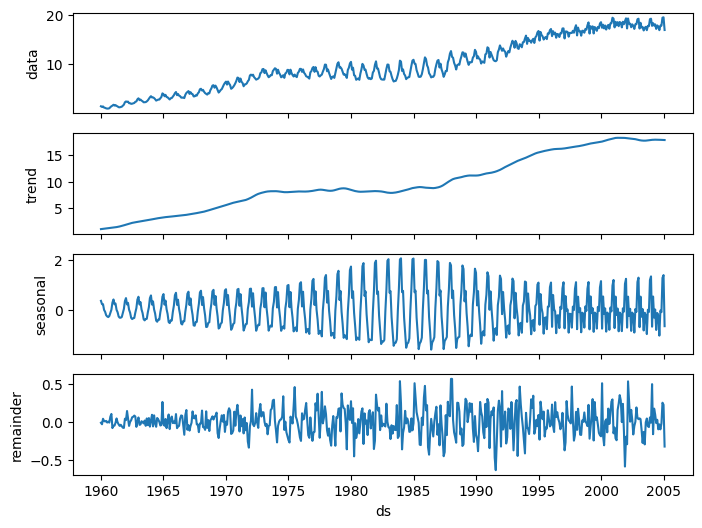

In [ ]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])